In [9]:
ds = load_dataset('docling-project/DocLayNet-v1.2', split='train', streaming=True)
sample = next(iter(ds))

print("All keys:", list(sample.keys()))
print()
for k, v in sample.items():
    if k != 'image':  # skip image bytes
        print(f"  {k}: {type(v).__name__} = {str(v)[:200]}")

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

All keys: ['image', 'bboxes', 'category_id', 'segmentation', 'area', 'pdf_cells', 'metadata', 'pdf', 'modalities']

  bboxes: list = [[72.35294285130719, 55.47565740740731, 372.2156845996732, 20.452899744572278], [100.1946343137255, 117.51495402298849, 789.325354248366, 42.370593869731806], [100.1946343137255, 166.60499233716473, 7
  category_id: list = [6, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 5, 8, 9, 9]
  segmentation: list = [[[72.35294285130719, 55.47565740740731, 72.35294285130719, 75.92855715197959, 444.5686274509804, 75.92855715197959, 444.5686274509804, 55.47565740740731]], [[100.1946343137255, 117.51495402298849, 10
  area: list = [7612.890080474451, 33444.1840159397, 44197.1989346708, 43927.393939856935, 31078.53406467767, 21682.392769707058, 33824.80331251684, 7783.082668507158, 45372.10108292853, 20082.67541732683, 45424.553
  pdf_cells: list = [[{'bbox': [72.35294285130719, 55.47565740740731, 372.2156845996732, 20.452899744572278], 'font': {'color': [0, 0, 0, 255], 'nam

# 📄 DocLayNet-v1.2 — Basic EDA
**Dataset:** `docling-project/DocLayNet-v1.2` (HuggingFace)

This notebook performs **Exploratory Data Analysis** on the DocLayNet dataset used for YOLO Document Layout Detection.

**11 Layout Classes:** `Caption`, `Footnote`, `Formula`, `List-item`, `Page-footer`, `Page-header`, `Picture`, `Section-header`, `Table`, `Text`, `Title`

## Cell 1 — Install & Import

In [10]:
# Install packages ONLY — do NOT restart here
# Just run this cell, then manually go to Runtime > Restart session,
# then continue from Cell 1b
!pip install -q --upgrade datasets matplotlib seaborn pillow tqdm
print(' Packages installed.')
print(' Now go to Runtime > Restart session, then run from Cell 1b onwards.')

 Packages installed.
 Now go to Runtime > Restart session, then run from Cell 1b onwards.


## Cell 1b — Imports (run this AFTER the runtime restarts)

In [11]:
# Run this cell after the runtime restarts from Cell 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print(' All imports ready!')

 All imports ready!


## Cell 2 — Load a Sample from HuggingFace (Streaming)

In [12]:
CLASSES = [
    'Caption', 'Footnote', 'Formula', 'List-item',
    'Page-footer', 'Page-header', 'Picture',
    'Section-header', 'Table', 'Text', 'Title'
]
# Dataset labels are 1-indexed integers
ID_TO_CLASS = {i+1: c for i, c in enumerate(CLASSES)}

SAMPLE_SIZE = 500

print(f'Streaming {SAMPLE_SIZE} samples...')
ds = load_dataset(
    'docling-project/DocLayNet-v1.2',
    split='train',
    streaming=True
    # trust_remote_code removed — no longer supported
)

# Inspect first sample to confirm field names
sample0 = next(iter(ds))
print("Keys in a sample:", list(sample0.keys()))
print("Example bboxes:", sample0.get('bboxes', sample0.get('bounding_boxes', []))[:2])
print("Example labels:", sample0.get('labels', [])[:5])

Streaming 500 samples...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Keys in a sample: ['image', 'bboxes', 'category_id', 'segmentation', 'area', 'pdf_cells', 'metadata', 'pdf', 'modalities']
Example bboxes: [[72.35294285130719, 55.47565740740731, 372.2156845996732, 20.452899744572278], [100.1946343137255, 117.51495402298849, 789.325354248366, 42.370593869731806]]
Example labels: []


## Cell 2b - Build the DataFrame once keys are confirmed

In [13]:
CLASSES = [
    'Caption', 'Footnote', 'Formula', 'List-item',
    'Page-footer', 'Page-header', 'Picture',
    'Section-header', 'Table', 'Text', 'Title'
]
ID_TO_CLASS = {i+1: c for i, c in enumerate(CLASSES)}

SAMPLE_SIZE = 500

ds = load_dataset('docling-project/DocLayNet-v1.2', split='train', streaming=True)

records = []
images_sample = []

for idx, sample in enumerate(tqdm(ds, total=SAMPLE_SIZE)):
    if idx >= SAMPLE_SIZE:
        break

    img = sample['image']
    img_w, img_h = img.size
    bboxes      = sample['bboxes']        # list of [x, y, w, h]
    cat_ids     = sample['category_id']   # list of ints, 1-indexed
    doc_cat     = sample['metadata'].get('doc_category', 'unknown')

    if idx < 6:
        images_sample.append({
            'img': img, 'bboxes': bboxes,
            'labels': cat_ids, 'w': img_w, 'h': img_h
        })

    for bbox, cat_id in zip(bboxes, cat_ids):
        x, y, w, h = bbox[:4]
        records.append({
            'sample_id' : idx,
            'img_w'     : img_w,
            'img_h'     : img_h,
            'doc_cat'   : doc_cat,
            'label'     : ID_TO_CLASS.get(cat_id, f'unknown_{cat_id}'),
            'label_id'  : cat_id,
            'x': x, 'y': y,
            'bbox_w'    : w,
            'bbox_h'    : h,
            'area'      : w * h,
            'area_frac' : (w * h) / (img_w * img_h) if img_w * img_h > 0 else 0,
            'aspect'    : w / h if h > 0 else 0,
        })

df = pd.DataFrame(records)
print(f' {len(df):,} annotations from {df["sample_id"].nunique()} images')
print(f'   Classes: {sorted(df["label"].unique())}')
df.head()

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

 6,026 annotations from 498 images
   Classes: ['Caption', 'Footnote', 'List-item', 'Page-footer', 'Page-header', 'Picture', 'Section-header', 'Table', 'Text', 'Title']


,sample_id,img_w,img_h,doc_cat,label,label_id,x,y,bbox_w,bbox_h,area,area_frac,aspect
0,0,1025,1025,financial_reports,Page-header,6,72.352943,55.475657,372.215685,20.452900,7612.890080,0.007246,18.198675
1,0,1025,1025,financial_reports,Text,10,100.194634,117.514954,789.325354,42.370594,33444.184016,0.031833,18.629084
2,0,1025,1025,financial_reports,Text,10,100.194634,166.604992,787.606972,56.115805,44197.198935,0.042068,14.035386
3,0,1025,1025,financial_reports,Text,10,100.194634,229.440241,782.798968,56.115805,43927.393940,0.041811,13.949706
4,0,1025,1025,financial_reports,Text,10,100.194634,292.275490,733.493001,42.370594,31078.534065,0.029581,17.311369


aspect = bbox_w / bbox_h 
area_frac = How big the object is relative to image size

## Cell 3 — Dataset Overview

In [14]:
print('=== Dataset Shape ===')
print(f'Total annotations  : {len(df):,}')
print(f'Unique images      : {df["sample_id"].nunique():,}')
print(f'Avg annotations/img: {len(df)/df["sample_id"].nunique():.1f}')
print(f'\n=== Columns ===')
print(df.dtypes)
print(f'\n=== Numeric Summary ===')
df[['bbox_w','bbox_h','area','area_frac','aspect']].describe().round(2)

=== Dataset Shape ===
Total annotations  : 6,026
Unique images      : 498
Avg annotations/img: 12.1

=== Columns ===
sample_id      int64
img_w          int64
img_h          int64
doc_cat       object
label         object
label_id       int64
x            float64
y            float64
bbox_w       float64
bbox_h       float64
area         float64
area_frac    float64
aspect       float64
dtype: object

=== Numeric Summary ===


,bbox_w,bbox_h,area,area_frac,aspect
count,6026.00,6026.00,6026.00,6026.00,6026.00
mean,359.75,76.96,37183.33,0.04,11.43
std,241.61,110.11,83361.57,0.08,12.38
min,3.30,3.43,30.52,0.00,0.02
25%,172.27,12.41,2702.81,0.00,2.97
50%,335.30,40.53,12553.27,0.01,7.02
75%,431.52,97.02,41079.59,0.04,15.14
max,1026.21,1025.33,1051865.94,1.00,112.09


## Cell 4 — Class Distribution

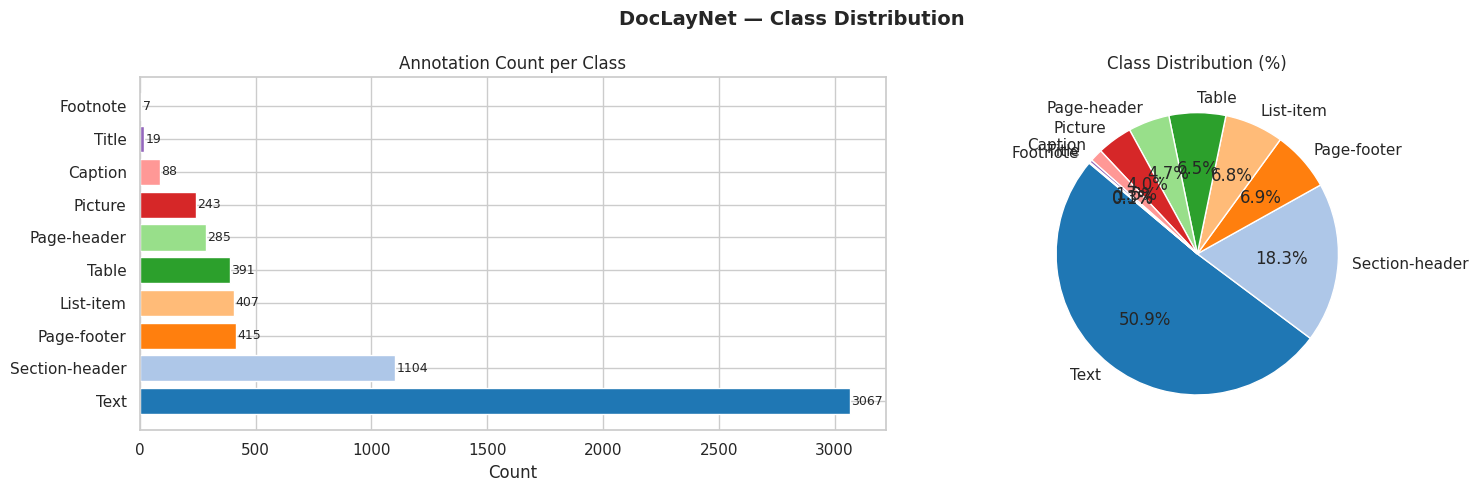

label
Text              3067
Section-header    1104
Page-footer        415
List-item          407
Table              391
Page-header        285
Picture            243
Caption             88
Title               19
Footnote             7


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df['label'].value_counts()
colors = sns.color_palette('tab20', len(counts))

axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Annotation Count per Class')
for i, val in enumerate(counts.values):
    axes[0].text(val + 5, i, str(val), va='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('DocLayNet — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(counts.to_string())

## Cell 5 — Annotations per Image

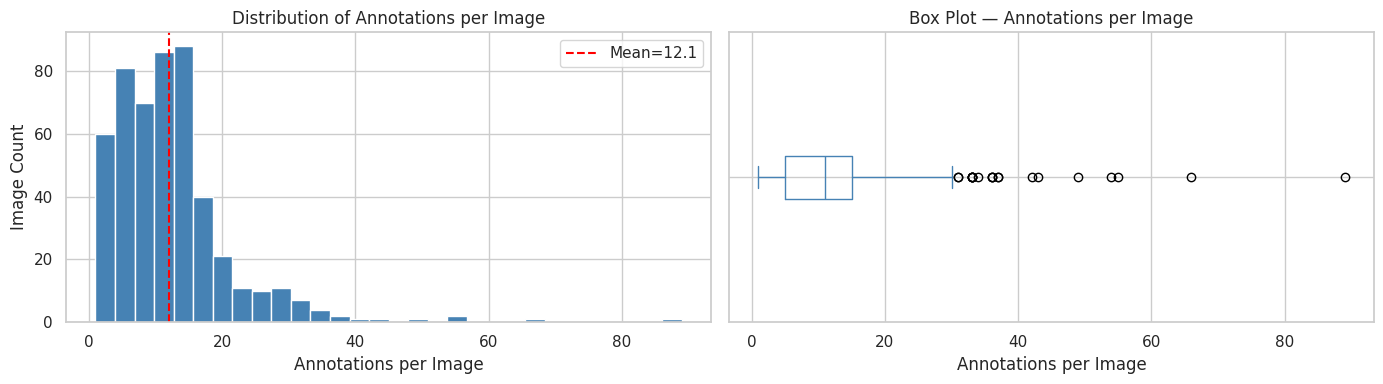

Min: 1 | Max: 89 | Mean: 12.1 | Median: 11.0


In [16]:
ann_per_img = df.groupby('sample_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ann_per_img, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(ann_per_img.mean(), color='red', linestyle='--',
                label=f'Mean={ann_per_img.mean():.1f}')
axes[0].set_xlabel('Annotations per Image')
axes[0].set_ylabel('Image Count')
axes[0].set_title('Distribution of Annotations per Image')
axes[0].legend()

ann_per_img.plot(kind='box', ax=axes[1], vert=False, color='steelblue')
axes[1].set_xlabel('Annotations per Image')
axes[1].set_title('Box Plot — Annotations per Image')

plt.tight_layout()
plt.show()
print(f'Min: {ann_per_img.min()} | Max: {ann_per_img.max()} | '
      f'Mean: {ann_per_img.mean():.1f} | Median: {ann_per_img.median()}')

## Cell 6 — Bounding Box Size Analysis

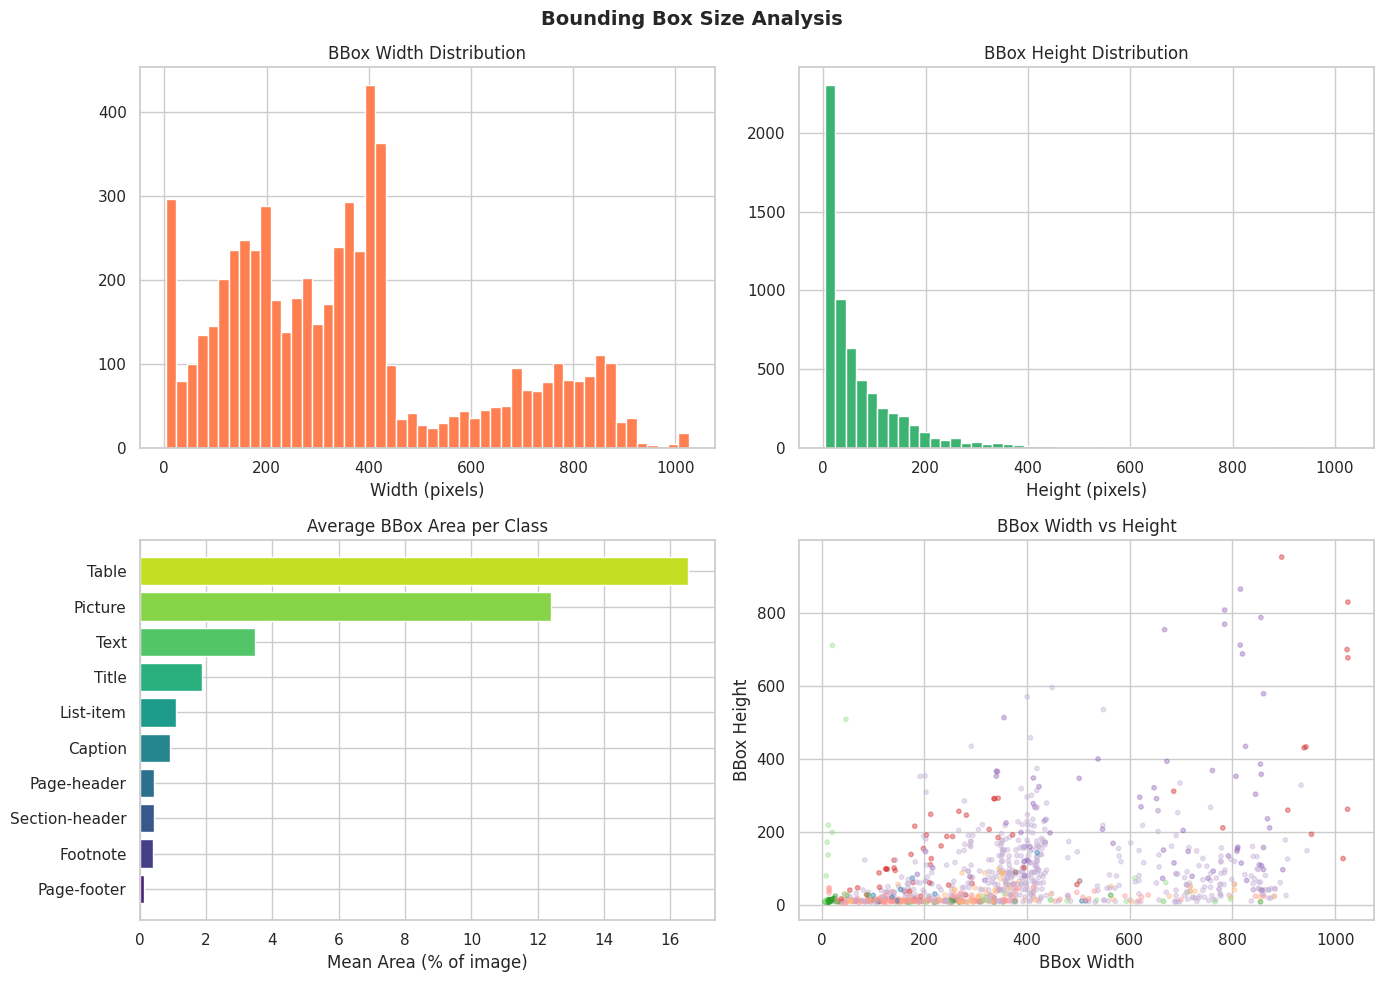

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['bbox_w'], bins=50, color='coral', edgecolor='white')
axes[0,0].set_title('BBox Width Distribution')
axes[0,0].set_xlabel('Width (pixels)')

axes[0,1].hist(df['bbox_h'], bins=50, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('BBox Height Distribution')
axes[0,1].set_xlabel('Height (pixels)')

class_area = df.groupby('label')['area_frac'].mean().sort_values()
axes[1,0].barh(class_area.index, class_area.values * 100,
               color=sns.color_palette('viridis', len(class_area)))
axes[1,0].set_xlabel('Mean Area (% of image)')
axes[1,0].set_title('Average BBox Area per Class')

sample = df.sample(min(1000, len(df)))
palette = sns.color_palette('tab20', len(CLASSES))
scatter_colors = [palette[CLASSES.index(l)] if l in CLASSES else (0.5,0.5,0.5)
                  for l in sample['label']]
axes[1,1].scatter(sample['bbox_w'], sample['bbox_h'],
                  c=scatter_colors, alpha=0.4, s=10)
axes[1,1].set_xlabel('BBox Width')
axes[1,1].set_ylabel('BBox Height')
axes[1,1].set_title('BBox Width vs Height')

plt.suptitle('Bounding Box Size Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7 — Aspect Ratio Analysis

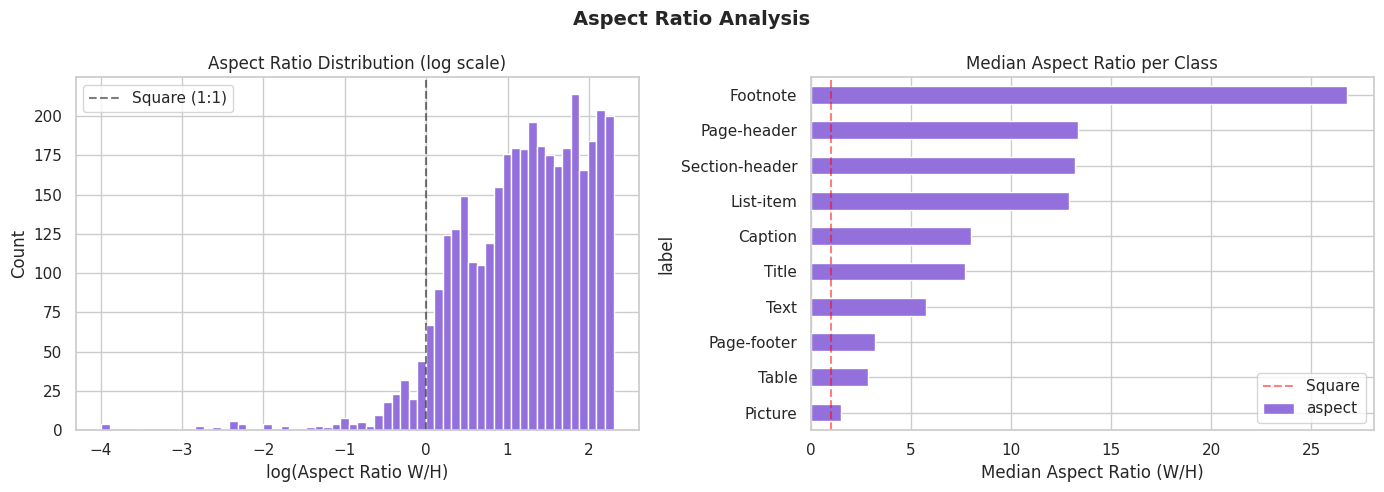

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clip = df[df['aspect'].between(0.01, 10)]
axes[0].hist(np.log(df_clip['aspect'] + 1e-5), bins=60,
             color='mediumpurple', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Square (1:1)')
axes[0].set_xlabel('log(Aspect Ratio W/H)')
axes[0].set_ylabel('Count')
axes[0].set_title('Aspect Ratio Distribution (log scale)')
axes[0].legend()

df.groupby('label')['aspect'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple')
axes[1].axvline(1, color='red', linestyle='--', alpha=0.5, label='Square')
axes[1].set_xlabel('Median Aspect Ratio (W/H)')
axes[1].set_title('Median Aspect Ratio per Class')
axes[1].legend()

plt.suptitle('Aspect Ratio Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 8 — BBox Position Heatmap

- spatially uniform
- Where objects are most concentrated
- Where they appear horizontally (left → right)

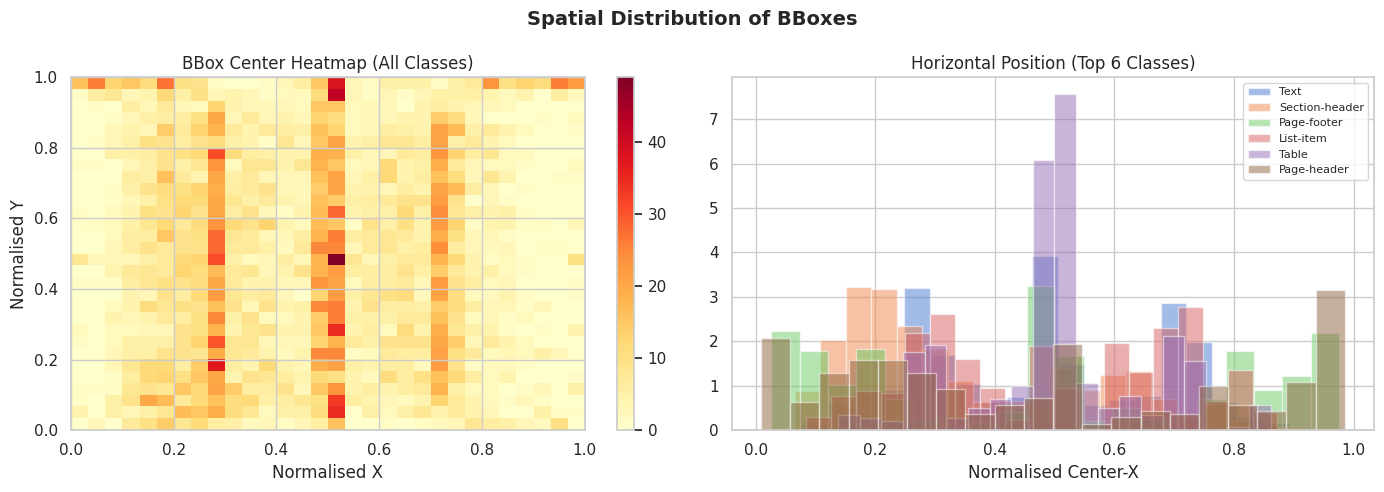

In [19]:
df['cx_norm'] = (df['x'] + df['bbox_w']/2) / df['img_w']
df['cy_norm'] = (df['y'] + df['bbox_h']/2) / df['img_h']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heatmap, _, _ = np.histogram2d(
    df['cx_norm'].clip(0,1), df['cy_norm'].clip(0,1), bins=30)
im = axes[0].imshow(heatmap.T, origin='lower', aspect='auto',
                    cmap='YlOrRd', extent=[0,1,0,1])
plt.colorbar(im, ax=axes[0])
axes[0].set_title('BBox Center Heatmap (All Classes)')
axes[0].set_xlabel('Normalised X')
axes[0].set_ylabel('Normalised Y')

top_classes = df['label'].value_counts().head(6).index.tolist()
for cls in top_classes:
    axes[1].hist(df[df['label']==cls]['cx_norm'],
                 bins=20, alpha=0.5, label=cls, density=True)
axes[1].set_xlabel('Normalised Center-X')
axes[1].set_title('Horizontal Position (Top 6 Classes)')
axes[1].legend(fontsize=8)

plt.suptitle('Spatial Distribution of BBoxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 9 — Class Co-occurrence Matrix

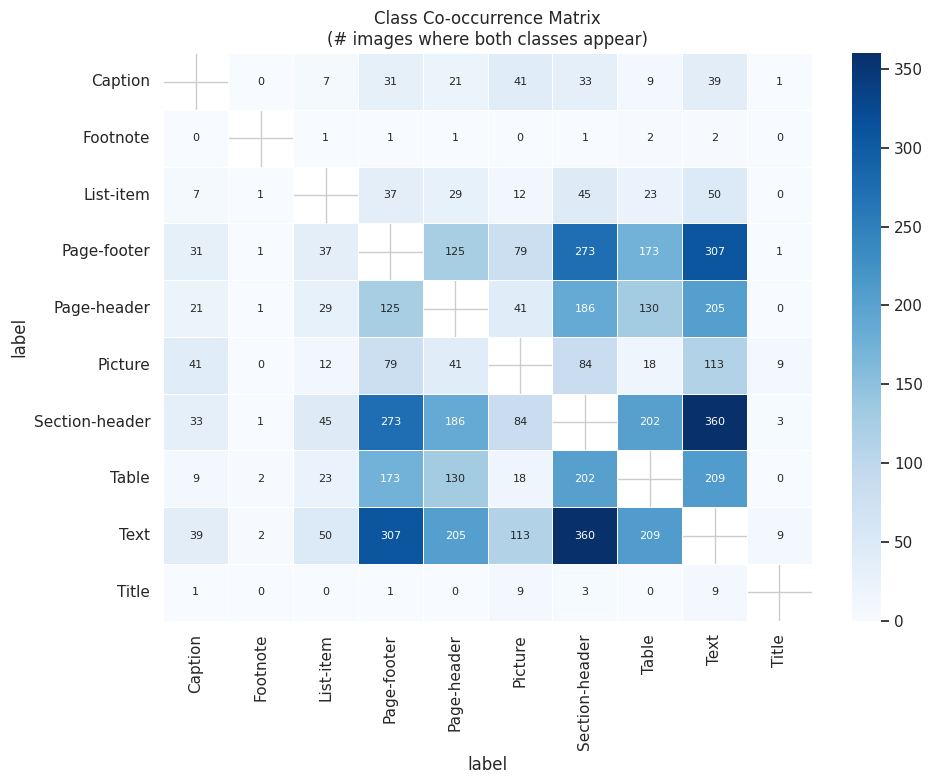

In [20]:
pivot = df.groupby(['sample_id','label']).size().unstack(fill_value=0).clip(upper=1)
pivot = pivot.reindex(columns=[c for c in CLASSES if c in pivot.columns], fill_value=0)
cooccurrence = pivot.T.dot(pivot)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(cooccurrence), dtype=bool)
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, mask=mask, annot_kws={'size': 8})
ax.set_title('Class Co-occurrence Matrix\n(# images where both classes appear)', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 10 — Sample Images with Ground Truth BBoxes

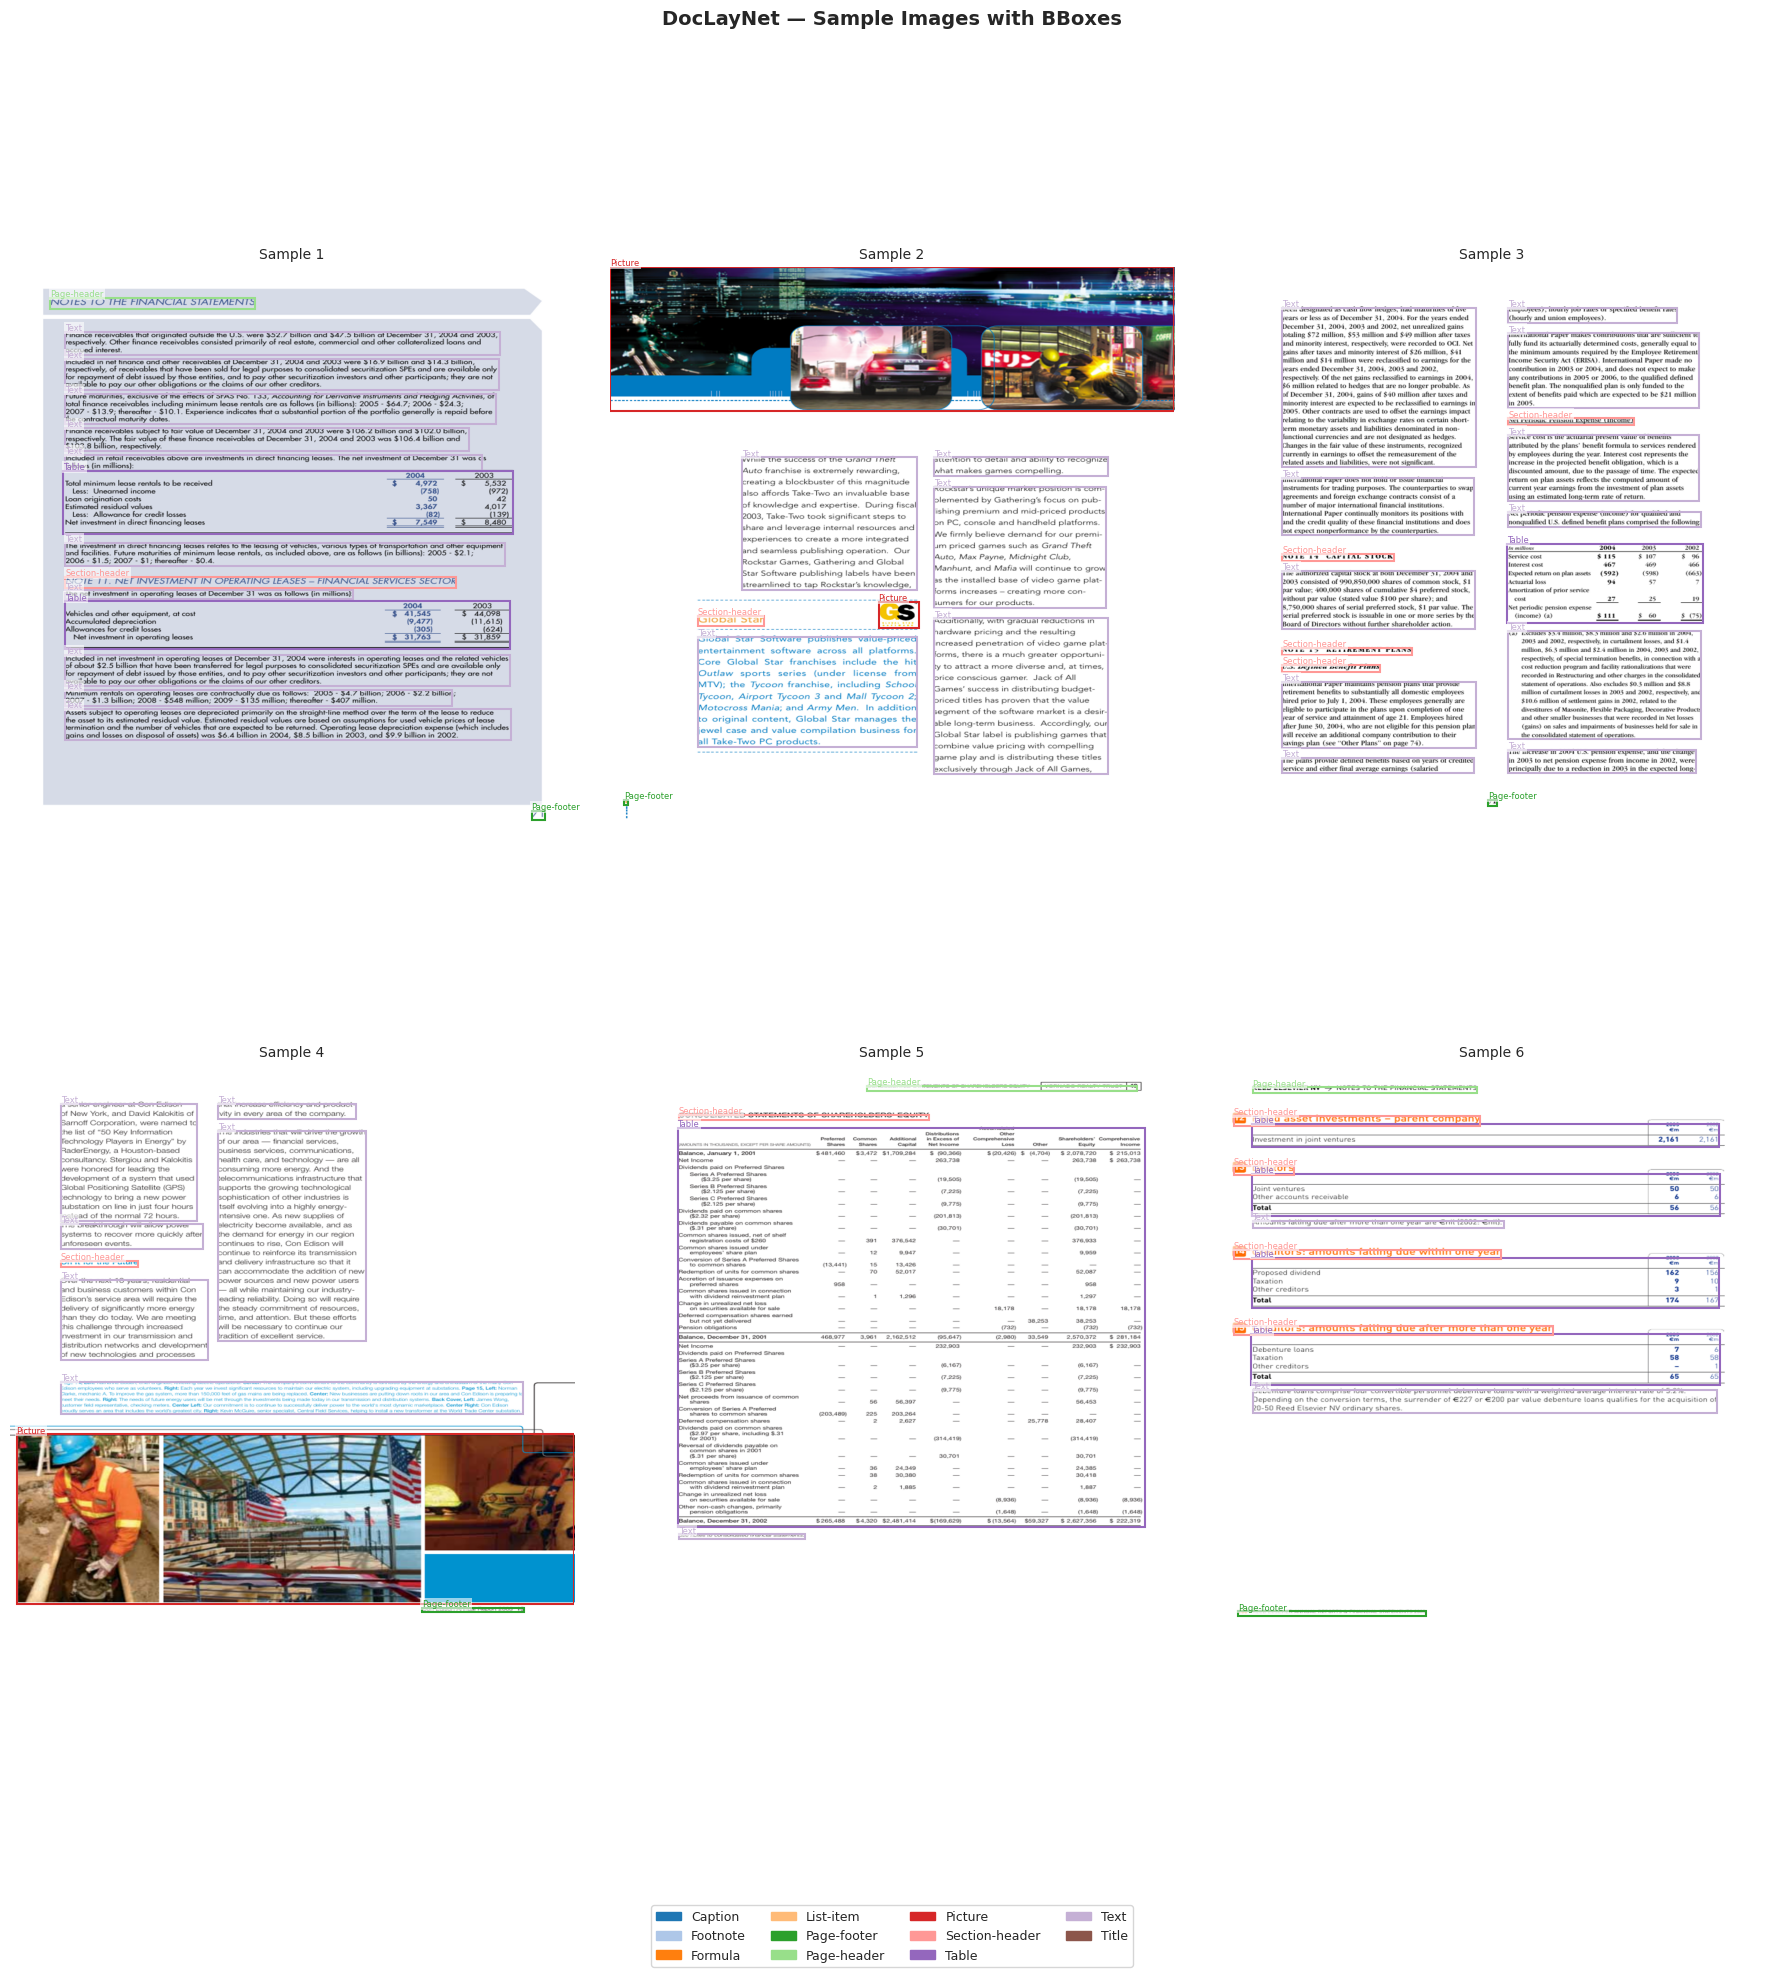

In [21]:
PALETTE = sns.color_palette('tab20', len(CLASSES))
CLASS_COLOR = {cls: PALETTE[i] for i, cls in enumerate(CLASSES)}

def visualize_sample(sd, ax):
    ax.imshow(sd['img'])
    for bbox, label_id in zip(sd['bboxes'], sd['labels']):
        x, y, w, h = bbox[:4]
        label = ID_TO_CLASS.get(label_id, '?')
        color = CLASS_COLOR.get(label, (1,0,0))
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                                        edgecolor=color, facecolor='none'))
        ax.text(x, y-3, label, color=color, fontsize=6,
                bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))
    ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(18, 20))
for i, ax in enumerate(axes.flat):
    if i < len(images_sample):
        visualize_sample(images_sample[i], ax)
        ax.set_title(f'Sample {i+1}', fontsize=10)
    else:
        ax.axis('off')

legend_patches = [patches.Patch(color=CLASS_COLOR[c], label=c) for c in CLASSES]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9)
plt.suptitle('DocLayNet — Sample Images with BBoxes', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Cell 11 — Image Resolution Analysis

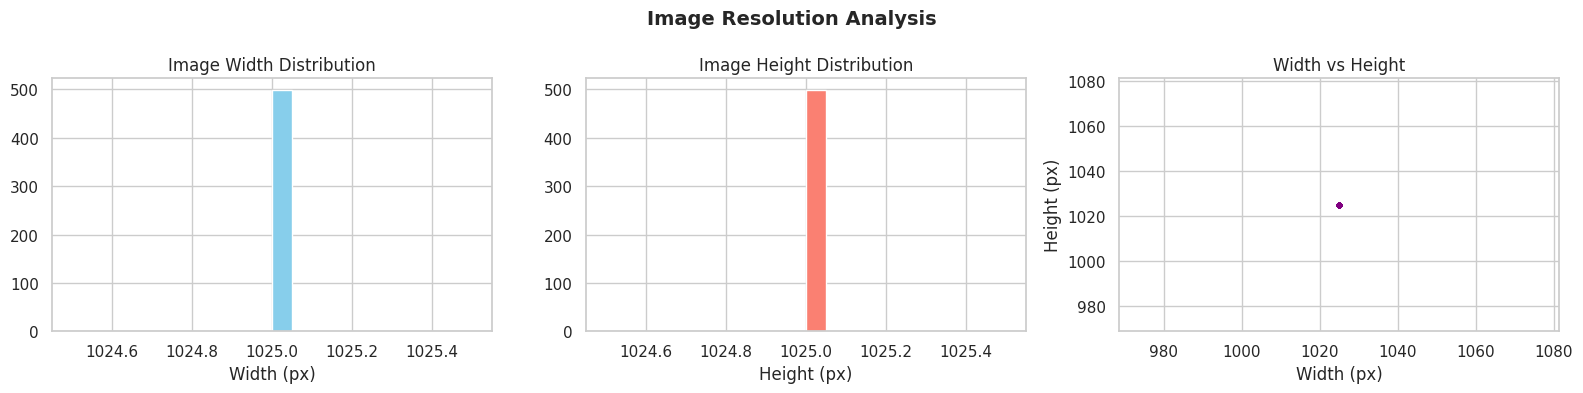

Most common resolution: (np.int64(1025), np.int64(1025))
        img_w   img_h
count   498.0   498.0
mean   1025.0  1025.0
std       0.0     0.0
min    1025.0  1025.0
25%    1025.0  1025.0
50%    1025.0  1025.0
75%    1025.0  1025.0
max    1025.0  1025.0


In [22]:
img_res = df[['sample_id','img_w','img_h']].drop_duplicates()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(img_res['img_w'], bins=20, color='skyblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')

axes[1].hist(img_res['img_h'], bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')

axes[2].scatter(img_res['img_w'], img_res['img_h'], alpha=0.4, color='purple', s=10)
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].set_title('Width vs Height')

plt.suptitle('Image Resolution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

most_common = img_res[['img_w','img_h']].value_counts().index[0]
print(f'Most common resolution: {most_common}')
print(img_res[['img_w','img_h']].describe().round(1))

## Cell 12 — EDA Summary

In [23]:
print('=' * 52)
print('       DocLayNet-v1.2  EDA Summary')
print('=' * 52)
print(f'Sample size          : {SAMPLE_SIZE} images')
print(f'Total annotations    : {len(df):,}')
print(f'Avg ann/image        : {len(df)/df["sample_id"].nunique():.1f}')
print(f'Number of classes    : {df["label"].nunique()}')
print()
print('Top 3 most frequent classes:')
for cls, cnt in df['label'].value_counts().head(3).items():
    print(f'  {cls:<18}: {cnt:>5}  ({cnt/len(df)*100:.1f}%)')
print()
print('Top 3 rarest classes:')
for cls, cnt in df['label'].value_counts().tail(3).items():
    print(f'  {cls:<18}: {cnt:>5}  ({cnt/len(df)*100:.1f}%)')
print()
print(f'Avg BBox Width  : {df["bbox_w"].mean():.0f}px')
print(f'Avg BBox Height : {df["bbox_h"].mean():.0f}px')
print(f'Avg Area Frac   : {df["area_frac"].mean()*100:.2f}% of image')
print('=' * 52)

       DocLayNet-v1.2  EDA Summary
Sample size          : 500 images
Total annotations    : 6,026
Avg ann/image        : 12.1
Number of classes    : 10

Top 3 most frequent classes:
  Text              :  3067  (50.9%)
  Section-header    :  1104  (18.3%)
  Page-footer       :   415  (6.9%)

Top 3 rarest classes:
  Caption           :    88  (1.5%)
  Title             :    19  (0.3%)
  Footnote          :     7  (0.1%)

Avg BBox Width  : 360px
Avg BBox Height : 77px
Avg Area Frac   : 3.54% of image
